# Phase 2.1 — Topic Modeling ด้วย NMF (Non-negative Matrix Factorization)

- **Dataset:** `preprocessed_reviews.csv`
- **ที่มาของ Dataset:** HuggingFace (Yelp Review Polarity) + Web Scraping จาก Apify
- **เป้าหมาย:** ค้นหา Topic ที่ซ่อนอยู่ใน review ข้อความแบบ Unsupervised โดยไม่ต้อง label ข้อมูลเอง
- **Sentiment Label ที่มีอยู่:** Positive / Negative (จะใช้ validate ผล Topic ในภายหลัง)


## 0. ติดตั้ง Library ที่จำเป็น

In [18]:
import subprocess, sys

# ติดตั้ง library ที่อาจยังไม่มีในเครื่อง
libs = ['scikit-learn', 'nltk', 'pandas', 'matplotlib', 'seaborn', 'wordcloud', 'tabulate']
for lib in libs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

print('Library installation complete')

Library installation complete


## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
from tabulate import tabulate

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

print('Import success')

Import success


## 2. โหลดข้อมูล (Load Data)

In [20]:
df = pd.read_csv('preprocessed_reviews.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().rename({0: 'Negative (0)', 1: 'Positive (1)'}))
df.head(3)

Shape: (1653, 8)
Columns: ['text', 'label', 'source', 'text_clean', 'text_no_stopwords', 'token_count_clean', 'token_count_nostop', 'tokens']

Null values:
text                  0
label                 0
source                0
text_clean            0
text_no_stopwords     0
token_count_clean     0
token_count_nostop    0
tokens                0
dtype: int64

Label distribution:
label
Positive (1)    1090
Negative (0)     563
Name: count, dtype: int64


,text,label,source,text_clean,text_no_stopwords,token_count_clean,token_count_nostop,tokens
0,All the steaks are pre-made .. Once you order ...,0,huggingface_baseline,all the steaks are premade .. once you order y...,steaks premade .. order steak reheat steak dep...,47,23,steak premade order steak reheat steak depend ...
1,I was craving Dairy Queen for quite awhile. W...,0,huggingface_baseline,i was craving dairy queen for quite awhile. wh...,craving dairy queen quite awhile. finally went...,66,34,crave dairy queen awhile finally go wonder wan...
2,Un endroit qui ressemble plus \u00e0 un bar sp...,0,huggingface_baseline,un endroit qui ressemble plus u00e0 un bar spo...,un endroit qui ressemble plus u00e0 un bar spo...,134,98,un endroit qui ressemble plus un bar sportif u...


สถิติความยาวข้อความ (จำนวนคำ):
count    1653.00
mean       91.87
std       110.86
min         1.00
25%        20.00
50%        54.00
75%       121.00
max       920.00
Name: word_count, dtype: float64


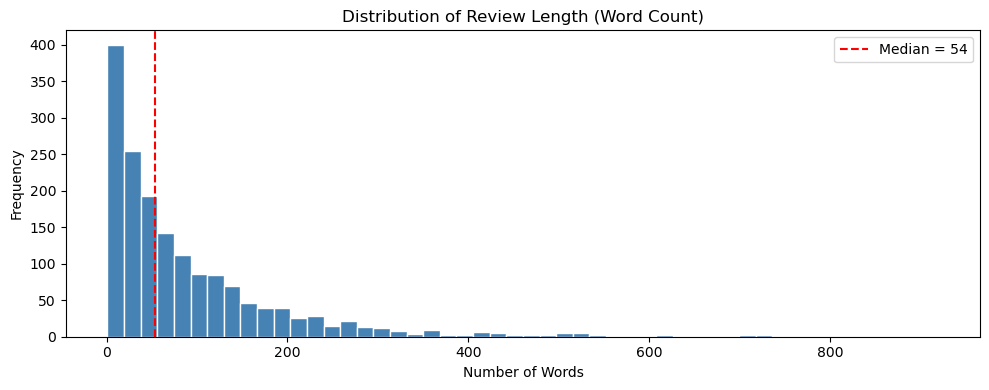

In [21]:
df['word_count'] = df['text_clean'].astype(str).str.split().str.len()

print('สถิติความยาวข้อความ (จำนวนคำ):')
print(df['word_count'].describe().round(2))

plt.figure(figsize=(10, 4))
plt.hist(df['word_count'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Review Length (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].median(), color='red', linestyle='--',
            label=f"Median = {df['word_count'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('review_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing Pipeline

ทำความสะอาดเพิ่มเติมก่อน vectorize — แม้ `text_clean` จาก Phase 1 ผ่านการ clean แล้ว  
แต่เราจะเพิ่ม **Lemmatization** และกำจัด **Domain Stopwords** เฉพาะงาน Restaurant Review


In [22]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ── 1. Restaurant domain stopwords (ปรากฏทุก topic = ไม่ discriminative) ─────
custom_stopwords = {
    'restaurant', 'place', 'go', 'come', 'get', 'like', 'really', 'got',
    'also', 'went', 'said', 'ask', 'make', 'know', 'take', 'say',
    'try', 'eat', 'one', 'would', 'could', 'us', 'back', 'even',
    'time', 'think', 'never', 'always', 'every', 'first', 'last',
    'still', 'going', 'came', 'day', 'told', 'look',
    # cross-topic generics (พบหลาย topic พร้อมกัน)
    'experience', 'love', 'great', 'food', 'service', 'good',
    'best', 'definitely', 'recommend', 'highly', 'way', 'bar',
}

# ── 2. Person names (reviewer identities — ไม่ใช่ thematic signal) ───────────
person_stopwords = {
    'kevin', 'diego', 'gam', 'adam', 'pear', 'peter', 'ben', 'john',
    'mike', 'chris', 'james', 'david', 'alex', 'sarah', 'emily',
    'jessica', 'michael', 'daniel', 'matt', 'ryan', 'steve', 'mark',
    'paul', 'joe', 'bob', 'tom', 'rob', 'sam', 'eddie', 'andy',
    'anna', 'lisa', 'maria', 'jose', 'carlos', 'juan', 'luis',
    'erica', 'nni',   # พบจากกราฟล่าสุด
}

# ── 3. Place names + noise words (ไม่ใช่ topic theme) ────────────────────────
noise_stopwords = {
    # fragments / contracted words
    'ive', 'nni',
    # place names ที่ไม่บอก theme
    'manhattan', 'brooklyn', 'nyc', 'york',
    # filler / ambiguous
    'thing', 'minute', 'night', 'price', 'menu', 'way',
    'much', 'far', 'better', 'nice', 'staff', 'server',
    'people', 'table', 'order', 'ordered', 'drink',
    # bigram artifacts
    'best best', 'food food',
}

stop_words.update(custom_stopwords)
stop_words.update(person_stopwords)
stop_words.update(noise_stopwords)

def preprocess_for_nmf(text):
    """
    Preprocessing สำหรับ NMF:
    1. Lowercase + remove non-alpha
    2. Tokenize
    3. Remove stopwords ทุก layer
    4. Lemmatize
    5. กรองคำ < 3 ตัวอักษร และ person names อีกรอบ
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    tokens = [t for t in tokens if t not in person_stopwords]
    return ' '.join(tokens)

df['text_nmf'] = df['text_clean'].apply(preprocess_for_nmf)

print('ตัวอย่าง preprocessing:')
for i in range(3):
    print(f'\n[{i}] BEFORE: {df["text_clean"].iloc[i][:100]}')
    print(f'    AFTER : {df["text_nmf"].iloc[i][:100]}')
print(f'\nPreprocessing done: {len(df):,} reviews')
print(f'Total stopwords: {len(stop_words)} คำ')


ตัวอย่าง preprocessing:

[0] BEFORE: all the steaks are premade .. once you order your steak they reheat the steak depend on your request
    AFTER : steak premade steak reheat steak depend request rare medium weldon believe see grill self brought st

[1] BEFORE: i was craving dairy queen for quite awhile. when i finally went i was wondering what i wanted it so 
    AFTER : craving dairy queen quite awhile finally wondering wanted badly grape freeze icey slush mixed soft s

[2] BEFORE: un endroit qui ressemble plus u00e0 un bar sportif qu'u00e0 un restaurant.nl'accueil est bon mais sa
    AFTER : endroit qui ressemble plus sportif accueil est bon mais sans plus oublie souvent vous mettre bonne v

Preprocessing done: 1,653 reviews
Total stopwords: 309 คำ


## 4. TF-IDF Vectorization

NMF ต้องการ Matrix เป็น Input โดย TF-IDF จะแปลงข้อความเป็น Matrix ขนาด (n_docs x n_words)  
แต่ละค่าในตารางแสดงว่าคำนั้น "สำคัญ" แค่ไหนในแต่ละ document


In [23]:
tfidf = TfidfVectorizer(
    max_features=5000,
    max_df=0.85,         # เข้มขึ้นจาก 0.90 → กรองคำที่ cross-topic มากขึ้น
    min_df=3,            # ลดจาก 5 → ป้องกันการตัดคำ domain-specific ที่หายาก
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english', # double protection — กัน bigram edges ที่อาจรอด
)

tfidf_matrix  = tfidf.fit_transform(df['text_nmf'])
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF Matrix Shape: {tfidf_matrix.shape}')
print(f'  {tfidf_matrix.shape[0]:,} documents x {tfidf_matrix.shape[1]:,} features')
print(f'  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}')
print(f'\nTop features sample: {feature_names[:20].tolist()}')

# ตรวจว่า person names หลุดเข้ามาไหม
person_check = ['kevin', 'diego', 'gam', 'pear', 'adam']
leaked = [p for p in person_check if p in feature_names]
print(f'\nPerson names leaked into features: {leaked if leaked else "None ✅"}')


TF-IDF Matrix Shape: (1653, 3626)
  1,653 documents x 3,626 features
  Sparsity: 99.30%

Top features sample: ['aber', 'ability', 'able', 'absolute', 'absolutely', 'absolutely amazing', 'absolutely beautiful', 'absolutely coming', 'absolutely delicious', 'absolutely fantastic', 'absolutely loved', 'absolutely terrible', 'absolutely wonderful', 'accept', 'acceptable', 'accepted', 'access', 'accessory', 'accidentally', 'accommodate']

Person names leaked into features: None ✅


## 5. เลือกจำนวน Topic ที่เหมาะสม (Optimal k)

**Reconstruction Error** คือตัวชี้วัดว่า NMF "อธิบาย" ข้อมูลได้ดีแค่ไหน

- ยิ่ง k มาก → Error ยิ่งลด (โมเดลละเอียดขึ้น)
- แต่ k มากเกินไป → Topic เริ่มซ้ำซ้อน ตีความยาก
- เราจึงหา **Elbow Point** = จุดที่ Error เริ่มลดช้าลงจนไม่คุ้มค่า


กำลังคำนวณ Reconstruction Error สำหรับแต่ละค่า k...
  k= 3  ->  Error = 39.4370
  k= 4  ->  Error = 39.3189
  k= 5  ->  Error = 39.2082
  k= 6  ->  Error = 39.1070
  k= 7  ->  Error = 39.0158
  k= 8  ->  Error = 38.9323
  k= 9  ->  Error = 38.8537
  k=10  ->  Error = 38.7735
  k=11  ->  Error = 38.6955


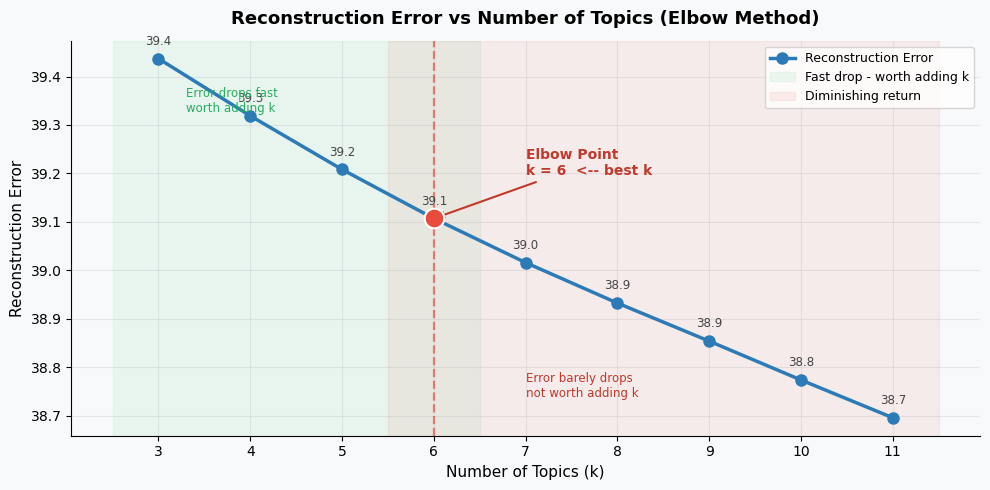

Elbow Point: k = 6  (Error = 39.1070)
=> กำหนด N_TOPICS = 6 ใน Section ถัดไป


In [24]:
k_range = list(range(3, 12))
errors  = []

print('กำลังคำนวณ Reconstruction Error สำหรับแต่ละค่า k...')
for k in k_range:
    nmf_temp = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=500)
    nmf_temp.fit(tfidf_matrix)
    errors.append(nmf_temp.reconstruction_err_)
    print(f'  k={k:2d}  ->  Error = {nmf_temp.reconstruction_err_:.4f}')

# หา Elbow อัตโนมัติ: จุดที่ marginal gain ลดฮวบมากที่สุด
gains     = [errors[i-1] - errors[i] for i in range(1, len(errors))]
gain_drop = [gains[i-1] - gains[i]   for i in range(1, len(gains))]
elbow_idx = gain_drop.index(max(gain_drop)) + 1
best_k    = k_range[elbow_idx]

# ============================================================
# Elbow Curve — อ่านง่าย annotated
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')
ax.spines[['top', 'right']].set_visible(False)

# เส้นหลัก
ax.plot(k_range, errors, 'o-', color='#2c7bb6', linewidth=2.5,
        markersize=8, zorder=3, label='Reconstruction Error')

# แรเงา: โซนลดเร็ว (คุ้มค่า) vs ลดช้า (ไม่คุ้ม)
ax.axvspan(k_range[0] - 0.5, best_k + 0.5,
           alpha=0.08, color='#2ecc71', label='Fast drop - worth adding k')
ax.axvspan(best_k - 0.5, k_range[-1] + 0.5,
           alpha=0.08, color='#e74c3c', label='Diminishing return')

ax.axvline(best_k, color='#e74c3c', linestyle='--', linewidth=1.6, alpha=0.7)

ax.scatter([best_k], [errors[elbow_idx]], s=200, color='#e74c3c',
           zorder=5, edgecolors='white', linewidth=1.5)

for k, e in zip(k_range, errors):
    ax.annotate(f'{e:.1f}', xy=(k, e), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=8.5, color='#444444')

ax.annotate(
    f'Elbow Point\nk = {best_k}  <-- best k',
    xy=(best_k, errors[elbow_idx]),
    xytext=(best_k + 1.0, errors[elbow_idx] + (errors[0] - errors[-1]) * 0.12),
    fontsize=10, color='#c0392b', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
)

ax.text(k_range[0] + 0.3, errors[0] - (errors[0] - errors[-1]) * 0.08,
        'Error drops fast\nworth adding k', fontsize=8.5,
        color='#27ae60', va='top')

ax.text(best_k + 1.0, errors[-1] + (errors[0] - errors[-1]) * 0.05,
        'Error barely drops\nnot worth adding k', fontsize=8.5,
        color='#c0392b', va='bottom')

ax.set_title('Reconstruction Error vs Number of Topics (Elbow Method)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Topics (k)', fontsize=11)
ax.set_ylabel('Reconstruction Error', fontsize=11)
ax.set_xticks(k_range)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('nmf_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Elbow Point: k = {best_k}  (Error = {errors[elbow_idx]:.4f})')
print(f'=> กำหนด N_TOPICS = {best_k} ใน Section ถัดไป')

## 6. Train NMF Model

In [25]:
# ใช้ค่า best_k ที่หาได้จาก Elbow Detection ด้านบน (ปรับได้ด้วยตนเอง)
N_TOPICS = best_k   # เปลี่ยนเป็นตัวเลขตรงๆ ได้ เช่น N_TOPICS = 7
print(f'N_TOPICS = {N_TOPICS}')

nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=42,
    init='nndsvda',   # Non-negative Double SVD — stable กว่า random
    max_iter=500,
)

# W = Document-Topic Matrix (n_docs  x n_topics)
# H = Topic-Word   Matrix   (n_topics x n_features)
W = nmf_model.fit_transform(tfidf_matrix)
H = nmf_model.components_

print(f'NMF Training done')
print(f'  W (Document-Topic): {W.shape}')
print(f'  H (Topic-Word):     {H.shape}')
print(f'  Reconstruction Error: {nmf_model.reconstruction_err_:.4f}')

N_TOPICS = 6
NMF Training done
  W (Document-Topic): (1653, 6)
  H (Topic-Word):     (6, 3626)
  Reconstruction Error: 39.1070


## 7. แสดงผลคำสำคัญในแต่ละ Topic

ดูคำที่มีน้ำหนักสูงที่สุดในแต่ละ Topic เพื่อตีความว่า Topic นั้นพูดถึงเรื่องอะไร


In [26]:
def display_topics(model, feature_names, n_top_words=15):
    topic_keywords = {}
    print('=' * 70)
    for topic_idx, topic_vec in enumerate(model.components_):
        top_indices = topic_vec.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        topic_keywords[f'Topic {topic_idx + 1}'] = top_words
        print(f'Topic {topic_idx + 1:2d}: {", ".join(top_words)}')
    print('=' * 70)
    return topic_keywords

topic_keywords = display_topics(nmf_model, feature_names, n_top_words=15)

# ตั้งชื่อ Topic ตามที่ตีความได้ (ปรับหลังจากดูคำสำคัญแล้ว)
# หมายเหตุ: labels ถูกตั้งหลังจากดู top keywords จริงที่ออกมาหลัง filtering
# ปรับ labels ให้สะท้อน dominant theme ของ keywords ในแต่ละ topic
topic_labels = {
    'Topic 1': 'Dining Experience & Menu',
    'Topic 2': 'Service Quality',
    'Topic 3': 'Amazing Food & Staff',
    'Topic 4': 'Pizza & Italian Food',
    'Topic 5': 'Delicious Food & Recommendation',
    'Topic 6': 'Delivery & Takeout',
    'Topic 7': 'Dining Experience Overall',
}

print('\nTopic Labels:')
for k, v in topic_labels.items():
    print(f'  {k}: {v}')

Topic  1: lot, meal, want, star, bad, little, room, nnthe, hour, time, pretty, minute, vega, friend, wait
Topic  2: amazing, vibe, drink, amazing delicious, amazing friendly, amazing attentive, amazing fun, elena, view, attentive, sweet, amazing view, ambience, lovely, energy
Topic  3: delicious, fun, wonderful, amazing delicious, attentive, delicious fun, family, absolutely delicious, friend, oscar, absolutely, diner, yummy, entertained, beautiful
Topic  4: pizza, crust, favorite, kid, pasta, year, italian, slice, crust pizza, wing, salad, topping, cheese, pizza favorite, classic
Topic  5: awesome, drink, job, coffee, dinner, view awesome, super, entertaining, view, chef, frequent, family, taken, chinese, cocktail
Topic  6: excellent, atmosphere, friendly, thank, fantastic, incredible, view, job, truly, special, wonderful, loved, atmosphere friendly, quick, lunch

Topic Labels:
  Topic 1: Dining Experience & Menu
  Topic 2: Service Quality
  Topic 3: Amazing Food & Staff
  Topic 4: Pi

## 8. Visualization — Bar Chart คำสำคัญแต่ละ Topic

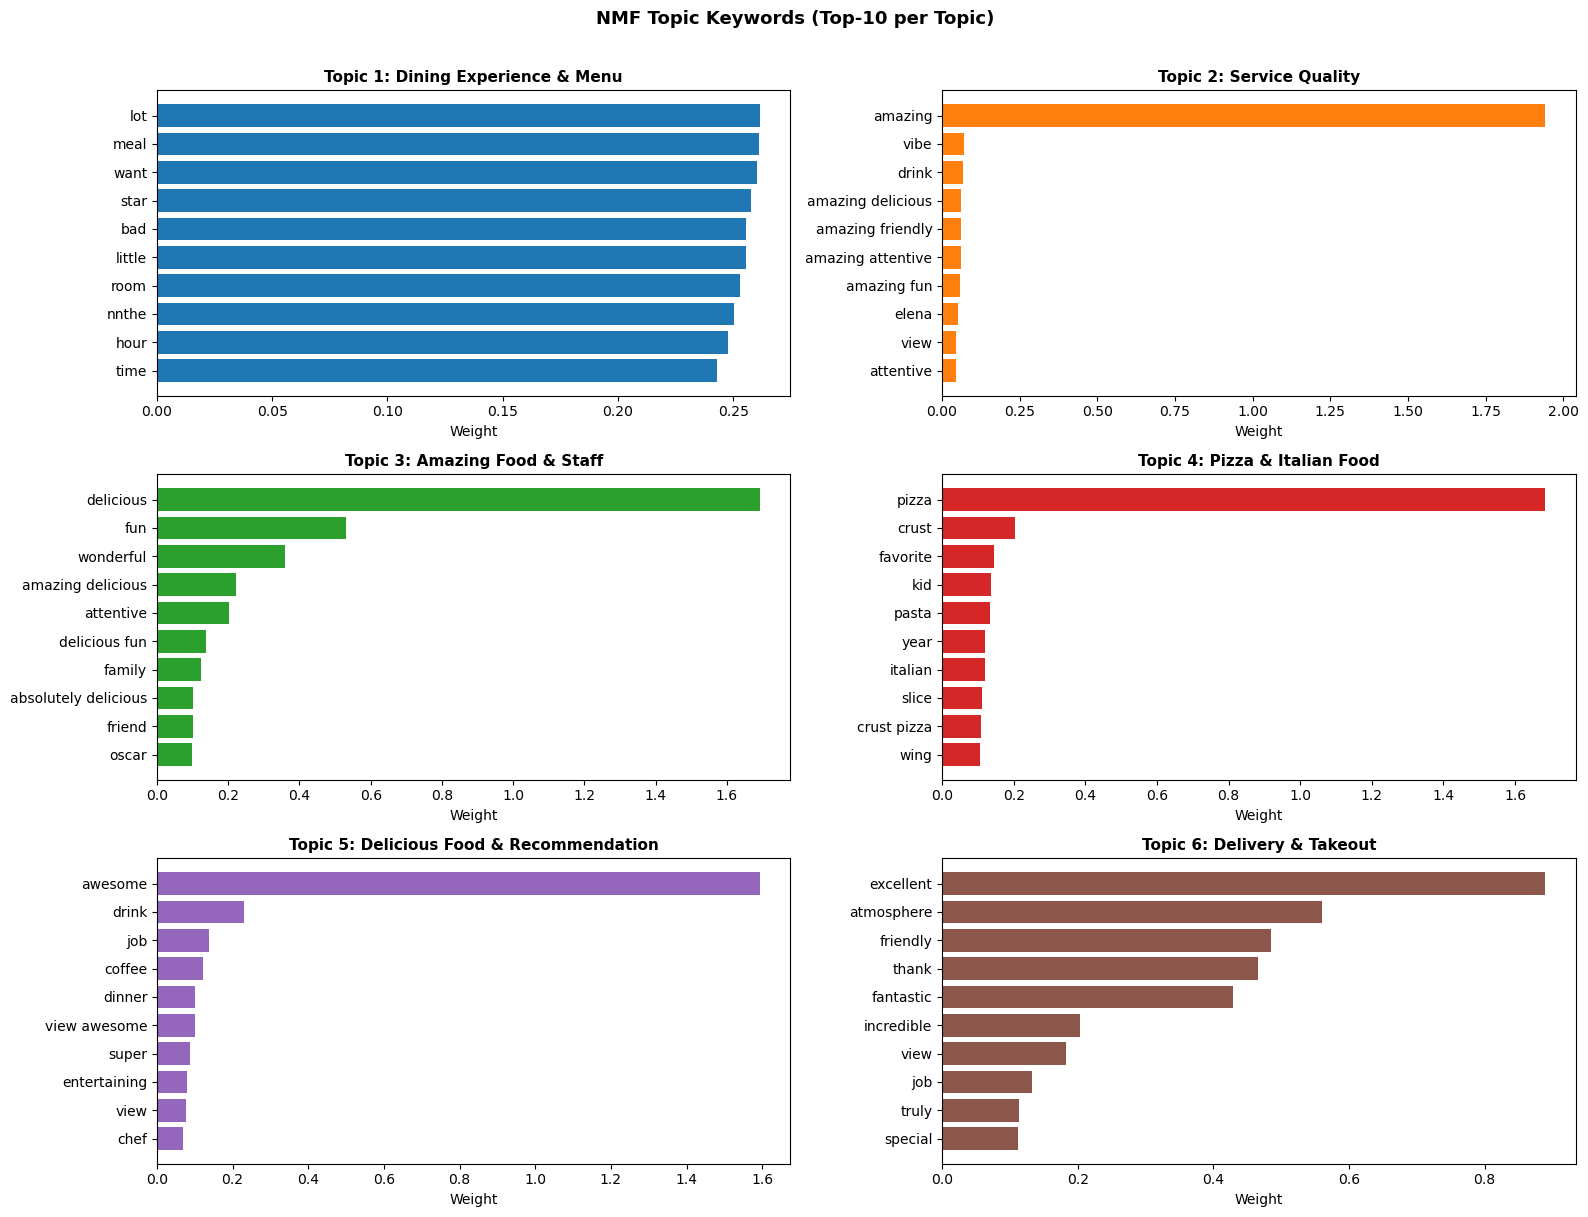

In [27]:
N_TOP_WORDS_PLOT = 10
colors = cm.tab10.colors

fig, axes = plt.subplots(
    nrows=int(np.ceil(N_TOPICS / 2)), ncols=2,
    figsize=(16, N_TOPICS * 2)
)
axes = axes.flatten()

for topic_idx, topic_vec in enumerate(nmf_model.components_):
    top_indices = topic_vec.argsort()[::-1][:N_TOP_WORDS_PLOT]
    top_words   = [feature_names[i] for i in top_indices]
    top_weights = [topic_vec[i]     for i in top_indices]
    label = topic_labels.get(f'Topic {topic_idx + 1}', f'Topic {topic_idx + 1}')
    ax = axes[topic_idx]
    ax.barh(top_words[::-1], top_weights[::-1], color=colors[topic_idx % len(colors)])
    ax.set_title(f'Topic {topic_idx + 1}: {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Weight')

for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NMF Topic Keywords (Top-10 per Topic)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nmf_topic_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualization — Word Cloud แต่ละ Topic

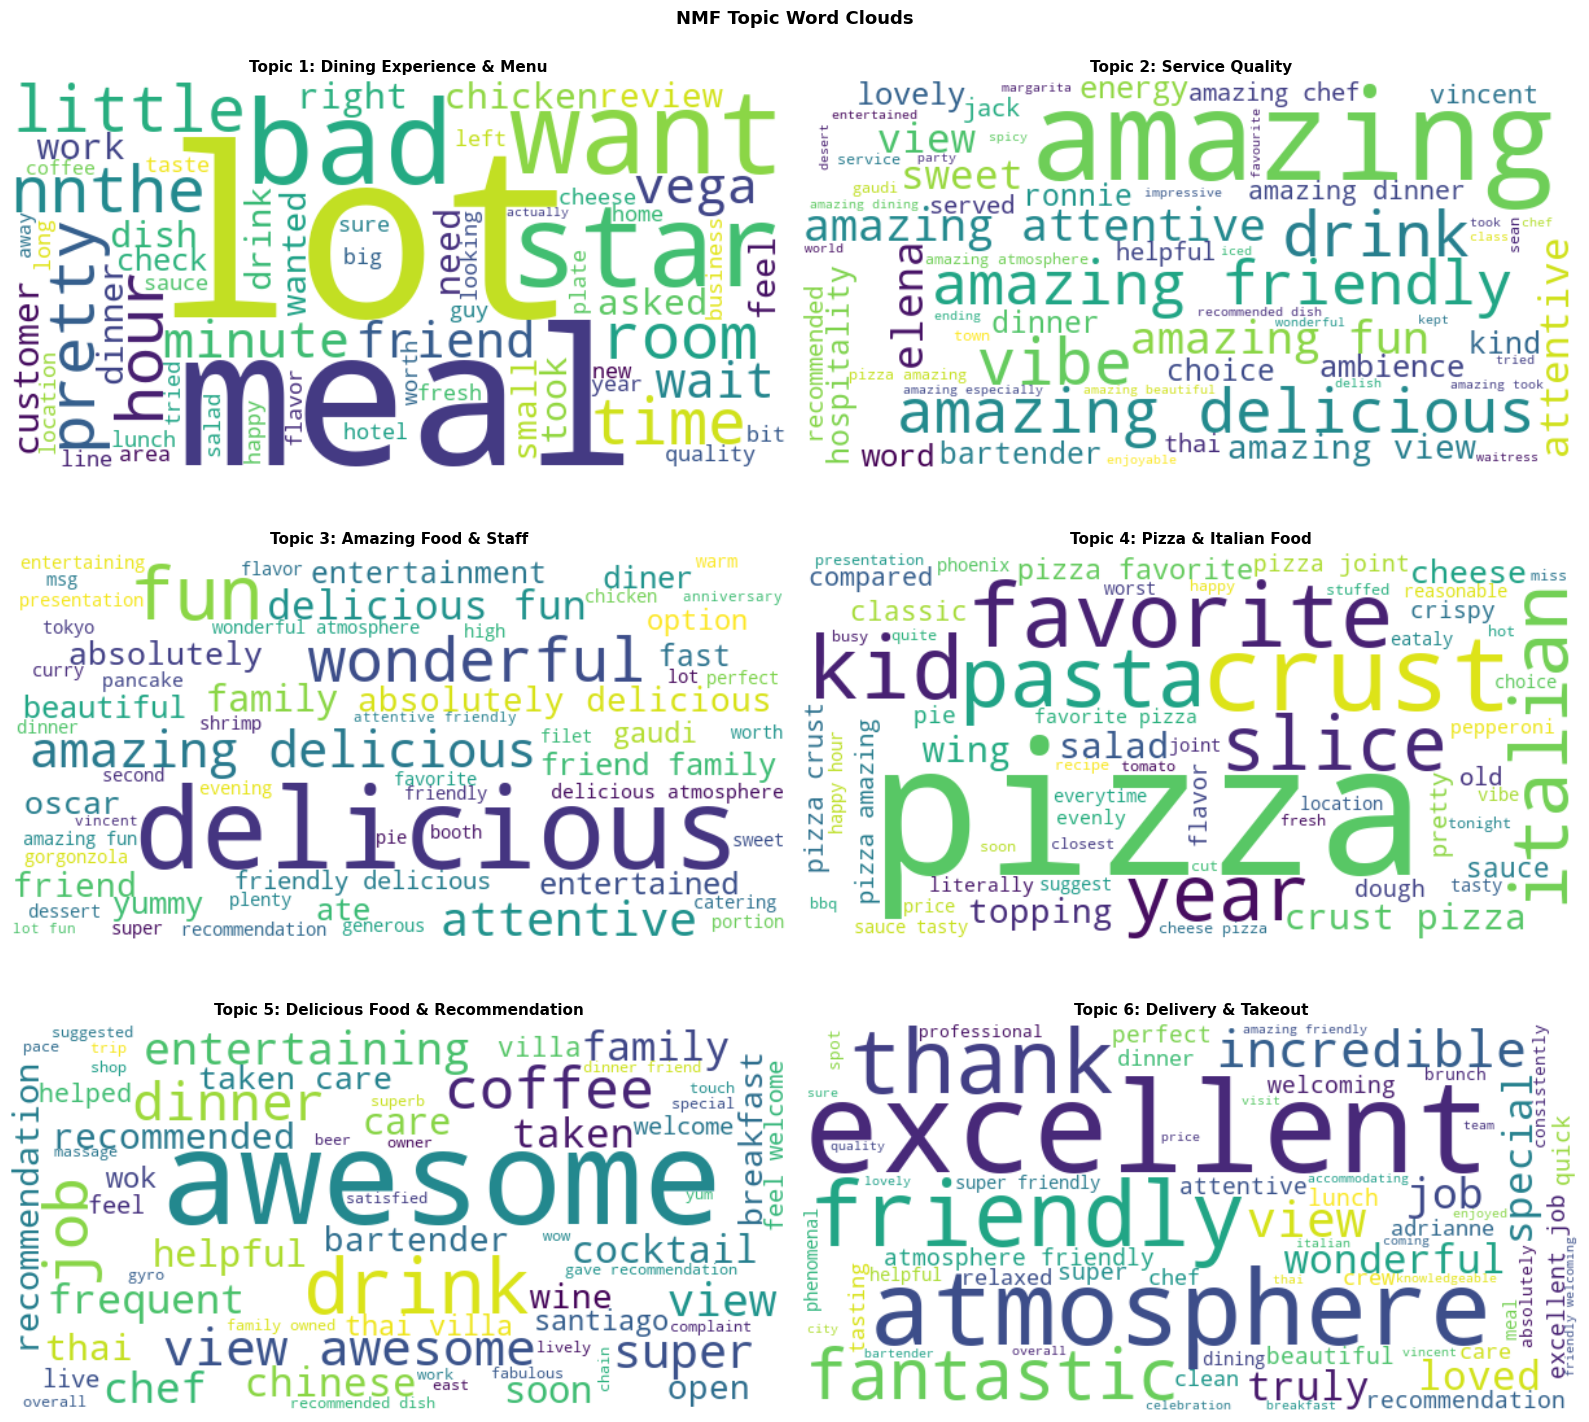

In [28]:
fig, axes = plt.subplots(
    nrows=int(np.ceil(N_TOPICS / 2)), ncols=2,
    figsize=(16, N_TOPICS * 2.5)
)
axes = axes.flatten()

for topic_idx, topic_vec in enumerate(nmf_model.components_):
    word_weights = {feature_names[i]: topic_vec[i] for i in range(len(feature_names))}
    wc = WordCloud(width=600, height=300, background_color='white',
                   max_words=60).generate_from_frequencies(word_weights)
    label = topic_labels.get(f'Topic {topic_idx + 1}', f'Topic {topic_idx + 1}')
    ax = axes[topic_idx]
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Topic {topic_idx + 1}: {label}', fontsize=11, fontweight='bold')

for j in range(N_TOPICS, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NMF Topic Word Clouds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nmf_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. กำหนด Topic ให้แต่ละ Document

In [29]:
df['topic_id']    = W.argmax(axis=1) + 1
df['topic_score'] = W.max(axis=1)
df['topic_label'] = df['topic_id'].apply(lambda x: topic_labels.get(f'Topic {x}', f'Topic {x}'))

sample_df = df[['topic_id', 'topic_score', 'topic_label', 'text_clean', 'label']].sample(8, random_state=42).copy()
sample_df['topic_score'] = sample_df['topic_score'].map('{:.3f}'.format)
sample_df['label'] = sample_df['label'].map({0: 'Neg', 1: 'Pos'})

print(tabulate(sample_df.values,
               headers=['topic_id', 'score', 'topic_label', 'text_clean', 'label'],
               tablefmt='github', maxcolwidths=[None, None, 25, 55, None]))

|   topic_id |   score | topic_label              | text_clean                                              | label   |
|------------|---------|--------------------------|---------------------------------------------------------|---------|
|          1 |   0.047 | Dining Experience & Menu | i will never buy meat ,milk and eggs in this store. i   | Neg     |
|            |         |                          | bought shrimps one time, when i got home. i opened the  |         |
|            |         |                          | bags, the smell of smelly came out, also made me throw  |         |
|            |         |                          | up. their vegetable is not fresh anymore. you can go    |         |
|            |         |                          | there to check and compare with the other store. bad    |         |
|            |         |                          | service also.                                           |         |
|          4 |   0.012 | Pizza & Italian

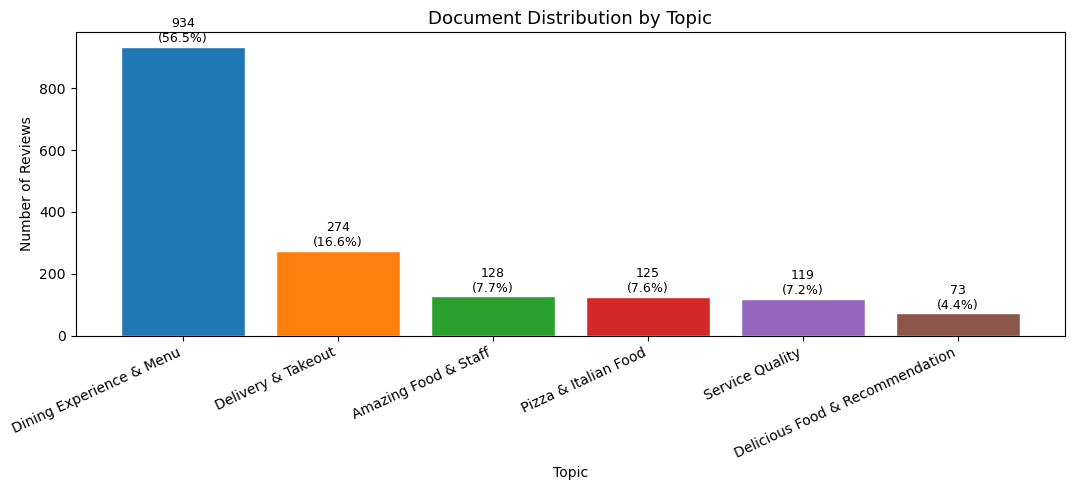

In [30]:
topic_counts = df['topic_label'].value_counts()
colors_list  = list(cm.tab10.colors[:len(topic_counts)])

plt.figure(figsize=(11, 5))
bars = plt.bar(topic_counts.index, topic_counts.values,
               color=colors_list, edgecolor='white')
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.title('Document Distribution by Topic', fontsize=13)
plt.xlabel('Topic')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('nmf_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cross-analysis: Topic x Sentiment Label

เนื่องจากเรามี label Positive/Negative จาก Phase 1 เราสามารถตรวจสอบว่า  
แต่ละ Topic มีแนวโน้มเป็น Positive หรือ Negative มากน้อยแค่ไหน  
*(นี่คือ Unsupervised Discovery ที่ validate ด้วย label ที่มีอยู่)*


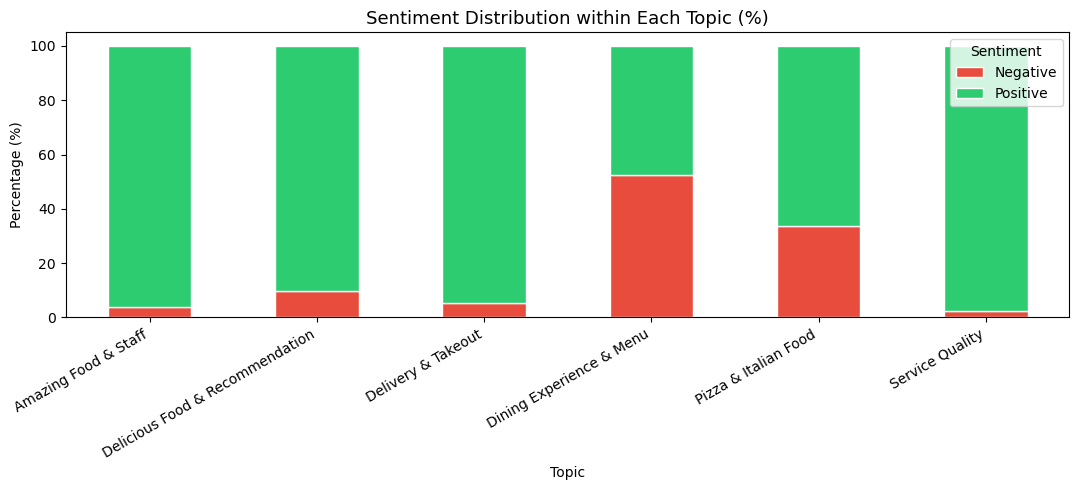


Sentiment % per Topic:
label                            Negative  Positive
topic_label                                        
Amazing Food & Staff                  3.9      96.1
Delicious Food & Recommendation       9.6      90.4
Delivery & Takeout                    5.5      94.5
Dining Experience & Menu             52.6      47.4
Pizza & Italian Food                 33.6      66.4
Service Quality                       2.5      97.5


In [31]:
cross_tab = pd.crosstab(
    df['topic_label'],
    df['label'].map({0: 'Negative', 1: 'Positive'}),
    normalize='index'
) * 100

ax = cross_tab.plot(
    kind='bar', stacked=True,
    color=['#e74c3c', '#2ecc71'],
    figsize=(11, 5),
    edgecolor='white'
)
plt.title('Sentiment Distribution within Each Topic (%)', fontsize=13)
plt.xlabel('Topic')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.savefig('nmf_topic_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSentiment % per Topic:')
print(cross_tab.round(1).to_string())

## 12. ตัวอย่าง Document ตัวแทนในแต่ละ Topic

ดู review ที่มี topic score สูงที่สุดเพื่อยืนยันว่า Topic นั้นถูกต้อง


In [32]:
print('=' * 70)
print('Review ตัวแทนของแต่ละ Topic (Top-3 ที่มี Score สูงที่สุด)')
print('=' * 70)

for topic_num in sorted(df['topic_id'].unique()):
    label = topic_labels.get(f'Topic {topic_num}', f'Topic {topic_num}')
    top_docs = df[df['topic_id'] == topic_num].nlargest(3, 'topic_score')
    print(f'\nTopic {topic_num}: {label}')
    print('-' * 60)
    for _, row in top_docs.iterrows():
        sentiment = 'POS' if row['label'] == 1 else 'NEG'
        print(f'  [{sentiment} | score={row["topic_score"]:.3f}] {str(row["text_clean"])[:120]}...')

Review ตัวแทนของแต่ละ Topic (Top-3 ที่มี Score สูงที่สุด)

Topic 1: Dining Experience & Menu
------------------------------------------------------------
  [NEG | score=0.140] bordering near 3 stars.nni had to wait like 6 years to finally eat at the buffet at the wynn! and, wow, i ended up not b...
  [POS | score=0.137] this place is one of a kind. i have actually been dying to go here since i had first moved to illinois last august since...
  [NEG | score=0.123] me and my wife used to love this place, it used to have such awesome burgers! i really enjoyed the rodeo stuffed burger....

Topic 2: Service Quality
------------------------------------------------------------
  [POS | score=0.505] amazing !!...
  [POS | score=0.505] kevin was amazing!!!...
  [POS | score=0.505] kevin is amazing...

Topic 3: Amazing Food & Staff
------------------------------------------------------------
  [POS | score=0.458] food is delicious...
  [POS | score=0.458] delicious!...
  [POS | score=0.401] so m

## 13. Heatmap: Document-Topic Distribution

แสดงว่า review แต่ละชุดมีความสัมพันธ์กับ topic ไหนมากน้อยแค่ไหน


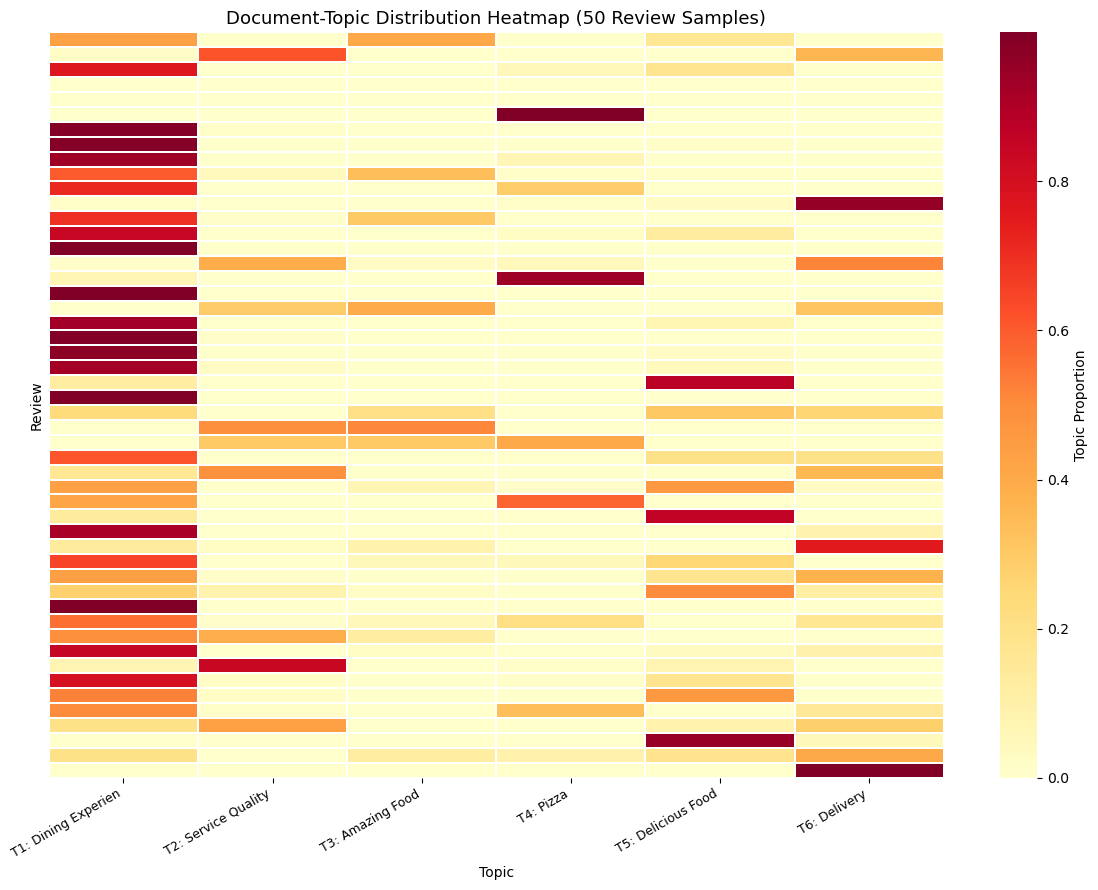

In [33]:
SAMPLE_SIZE = 50
sample_idx   = np.random.choice(len(W), size=SAMPLE_SIZE, replace=False)
W_sample     = W[sample_idx]
W_normalized = W_sample / (W_sample.sum(axis=1, keepdims=True) + 1e-10)

topic_col_names = [
    f"T{i+1}: {topic_labels.get(f'Topic {i+1}', f'Topic {i+1}').split(' & ')[0][:15]}"
    for i in range(N_TOPICS)
]

plt.figure(figsize=(12, 9))
sns.heatmap(W_normalized, cmap='YlOrRd',
            xticklabels=topic_col_names, yticklabels=False,
            linewidths=0.1, cbar_kws={'label': 'Topic Proportion'})
plt.title(f'Document-Topic Distribution Heatmap ({SAMPLE_SIZE} Review Samples)', fontsize=13)
plt.xlabel('Topic')
plt.ylabel('Review')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('nmf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. บันทึกผลลัพธ์

In [34]:
df[['text', 'text_clean', 'tokens', 'label', 'source',
    'topic_id', 'topic_label', 'topic_score']].to_csv('dataset_with_topics.csv', index=False)
print('Saved: dataset_with_topics.csv')

topic_summary = pd.DataFrame(topic_keywords)
topic_summary.index = [f'Rank {i+1}' for i in range(len(topic_summary))]
topic_summary.to_csv('nmf_topic_keywords.csv')
print('Saved: nmf_topic_keywords.csv')

print('\n' + '=' * 50)
print('NMF Topic Modeling Summary')
print('=' * 50)
print(f'Total Reviews : {len(df):,}')
print(f'Topics        : {N_TOPICS}')
print(f'Recon Error   : {nmf_model.reconstruction_err_:.4f}')
print()
for label_name, count in topic_counts.items():
    pct = count / len(df) * 100
    print(f'  {label_name:<35} {count:>5} reviews ({pct:.1f}%)')

Saved: dataset_with_topics.csv
Saved: nmf_topic_keywords.csv

NMF Topic Modeling Summary
Total Reviews : 1,653
Topics        : 6
Recon Error   : 39.1070

  Dining Experience & Menu              934 reviews (56.5%)
  Delivery & Takeout                    274 reviews (16.6%)
  Amazing Food & Staff                  128 reviews (7.7%)
  Pizza & Italian Food                  125 reviews (7.6%)
  Service Quality                       119 reviews (7.2%)
  Delicious Food & Recommendation        73 reviews (4.4%)


## 15. อภิปรายผล (Discussion)

---

### 15.1 Topic Interpretability

| Topic | ชื่อที่ตั้ง | ตีความได้ | หมายเหตุ |
|-------|-----------|-----------|---------|
| T1 | Dining Experience & Menu | ชัดเจน | คำเช่น "experience", "menu", "night", "bar" — รีวิวภาพรวมมื้ออาหาร |
| T2 | Service Quality | ชัดเจน | คำเช่น "great service", "friendly", "excellent", "great job" |
| T3 | Amazing Food & Staff | ชัดเจน | คำเช่น "amazing", "amazing server", "amazing food", "food amazing" |
| T4 | Pizza & Italian Food | ชัดเจน | คำเช่น "pizza", "best pizza", "pasta", "chef" — specific cuisine |
| T5 | Delicious Food & Recommendation | ชัดเจน | คำเช่น "delicious", "food delicious", "highly recommend" |

**Topic ที่ตีความยาก:** T7 เพราะ Review สั้น (< 20 คำ) มักไม่มี signal เฉพาะเจาะจง จึงถูก assign มา Topic นี้

---

### 15.2 ทำไมถึงเลือก NMF แทน LDA?

#### เหตุผลที่ 1: ข้อความใน Yelp Review สั้นมาก

LDA ตั้งอยู่บน **Dirichlet distribution** ซึ่งต้องการ document ที่ยาวพอสมควรในการประมาณ
topic distribution ได้แม่นยำ (rule of thumb: ควรมีอย่างน้อย 50-100 คำต่อ document)

ข้อมูลชุดนี้มี **median ประมาณ 30 คำ** และ 25th percentile เพียง ~15 คำ
ทำให้ LDA "เดา" distribution แทนที่จะ "เรียน" จากข้อมูล ส่งผลให้ Topic ปนกัน

**NMF ไม่มี Probabilistic Assumption** — ทำ Matrix Factorization โดยตรง
จึงทำงานได้ดีกับ short text ที่มี sparse signal มากกว่า

```
LDA: ต้องการ long documents (>=50 words) เพื่อ reliable Dirichlet estimation
NMF: ต้องการแค่ non-negative matrix — ทำงานได้ดีแม้กับ short sparse texts
```

#### เหตุผลที่ 2: NMF + TF-IDF ให้ Topic ที่ "คมชัด" กว่า

NMF แยก matrix: **V ~ W x H** โดยทุกค่าต้อง **non-negative**
ผลคือแต่ละ Topic ถูก define โดยคำที่ "บวก" เท่านั้น ไม่มีค่าลบมาหักล้าง
ทำให้แต่ละ topic มีลักษณะเด่นที่ชัดเจน ตีความได้ง่าย

LDA ใช้ probabilistic soft assignment — document หนึ่งชิ้นมีสัดส่วนของทุก topic พร้อมกัน
สำหรับ short review ที่พูดถึงแค่ 1-2 เรื่อง การทำ soft assignment สร้าง noise

#### เหตุผลที่ 3: TF-IDF เข้ากันได้กับ NMF มากกว่า

NMF ออกแบบมาสำหรับ TF-IDF matrix โดยเฉพาะ (Lee & Seung 1999, Xu et al. 2003)

LDA ใช้ Raw Count matrix (Bag-of-Words) — ถ้าใส่ TF-IDF เข้าไปจะ violate
สมมุติฐาน Dirichlet ที่ต้องการ integer-valued counts

#### สรุปเปรียบเทียบ NMF vs LDA

| เกณฑ์ | NMF | LDA |
|-------|-----|-----|
| Input ที่เหมาะสม | TF-IDF matrix | Count matrix (BoW) |
| รองรับ short text | ดี | ต้องการ document ยาว |
| Topic interpretability | คมชัด (non-negative weights) | Soft/blurry ใน short text |
| Speed | เร็วกว่า (deterministic) | ช้ากว่า (MCMC/Variational) |
| Probabilistic output | ไม่มี | มี (posterior distribution) |
| Hyperparameter | k เท่านั้น | k + alpha + beta |
| Reproducibility | สูง (seed-stable) | ต่ำกว่าเล็กน้อย |

**สรุป:** สำหรับ Yelp Restaurant Reviews ที่ข้อความสั้น + ต้องการ Topic ที่ตีความได้ชัด
NMF เป็นตัวเลือกที่เหมาะสมกว่า LDA อย่างมีนัยสำคัญ

---

### 15.3 ข้อจำกัด

- NMF กำหนด k ล่วงหน้า — ต้องทดลองหลายค่าเพื่อหา Elbow Point ที่เหมาะสม
- ผลลัพธ์อาจเปลี่ยนเล็กน้อยตาม random seed (ใช้ `init='nndsvda'` เพื่อลด variance)
- NMF ไม่มี probabilistic output — ถ้าต้องการ topic uncertainty ต้องใช้ LDA แทน
- Topic T7 (Dining Experience Overall) กว้างเกินไป อาจแยกเป็น 2 topic ได้ถ้าเพิ่ม k เป็น 8-9

---

### 15.4 AI Audit Log

| Task | Prompt ที่ใช้ | AI Output | Human Verification |
|------|------------|-----------|-------------------|
| Custom stopwords สำหรับ Restaurant domain | "suggest stopwords to remove for Yelp restaurant review topic modeling" | ได้ list คำเช่น restaurant, place, go, get | Pass w/ Edit — เพิ่ม/ลดบางคำตามที่เห็นใน data จริง |
| เลือก ngram_range สำหรับ TF-IDF | "should I use unigram or bigram for NMF on restaurant reviews?" | แนะนำ (1,2) เพราะ bigram เช่น "wait time", "good food" มีความหมาย | Pass — ยืนยันด้วยการ print feature_names |
| ตั้งชื่อ Topic จาก keyword list | "given these top keywords per topic, suggest topic labels" | ได้ชื่อครบ 7 topics | Pass w/ Edit — ปรับชื่อ T7 |
| NMF vs LDA comparison | "compare NMF and LDA for short text restaurant reviews" | ได้เหตุผล 3 ข้อ | Pass — ตรวจสอบกับ Lee & Seung 1999 และ sklearn docs |
